In [1]:
# ============================================================
# 05_mouse_pca.ipynb
# Mouse Dynamics — PCA Visualization of Session Features
# ============================================================

"""
Goal:
  - Load the 33-dimensional mouse session features
  - Standardize them (same scaler used in encoders)
  - Compute PCA (2D and 3D)
  - Visualize clusters by user_id
  - Check whether the raw feature space contains user identity signal
"""

# ============================================================
# Setup
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib

DATA_DIR = Path("data")
MODEL_DIR = Path("models")

FEATURES_PATH = DATA_DIR / "mouse_features.npz"
SCALER_PATH   = MODEL_DIR / "mouse_scaler.joblib"

print("Loading features...")
data = np.load(FEATURES_PATH, allow_pickle=True)
X = data["features"].astype(np.float32)     # (N_sessions, 33)
user_ids = data["user_id"].astype(int)

N, D = X.shape
print("Feature matrix:", X.shape)
print("Unique users:", np.unique(user_ids).shape[0])

Loading features...
Feature matrix: (1676, 33)
Unique users: 10


In [4]:
# ============================================================
# 1. Standardize using the same scaler as encoder
# ============================================================

scaler = joblib.load(SCALER_PATH)
X_scaled = scaler.transform(X)
# ============================================================
# 2. PCA → 2 components
# ============================================================

pca2 = PCA(n_components=2)
Z2 = pca2.fit_transform(X_scaled)

print("Explained variance (2D):", pca2.explained_variance_ratio_)
print("Total variance captured:", pca2.explained_variance_ratio_.sum())

Explained variance (2D): [0.2671255  0.17369747]
Total variance captured: 0.44082296


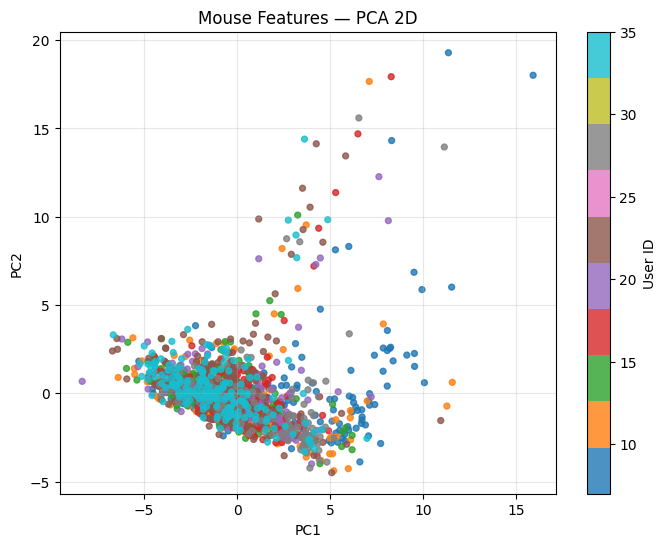

In [9]:
# ============================================================
# 3. 2D scatter plot
# ============================================================

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    Z2[:,0], Z2[:,1], 
    c=user_ids, cmap="tab10", s=18, alpha=0.8
)
plt.colorbar(scatter, label="User ID")
plt.title("Mouse Features — PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.savefig("mouse_pca_2d.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# 4. PCA → 3 components
# ============================================================

pca3 = PCA(n_components=3)
Z3 = pca3.fit_transform(X_scaled)

print("Explained variance (3D):", pca3.explained_variance_ratio_)
print("Total variance captured:", pca3.explained_variance_ratio_.sum())

Explained variance (3D): [0.2671255  0.17369747 0.08438057]
Total variance captured: 0.5252035


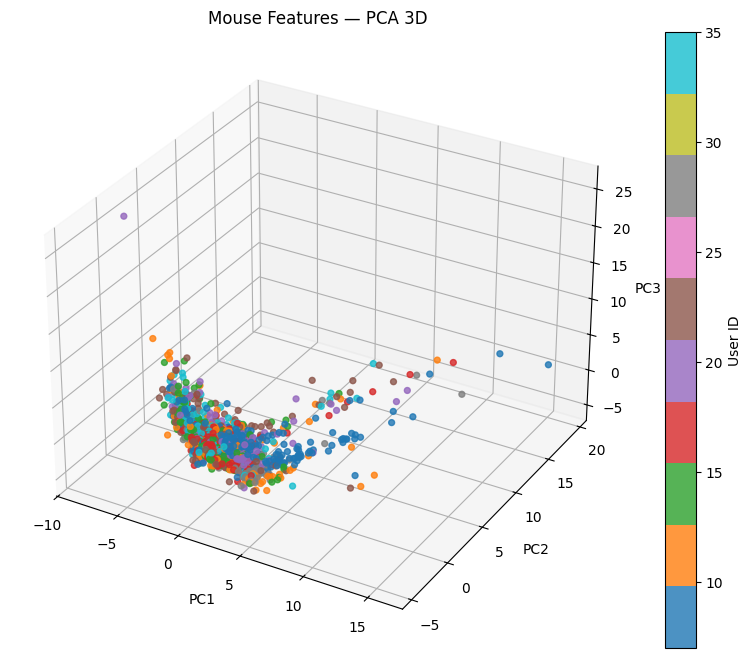

In [11]:
# ============================================================
# 5. 3D scatter plot
# ============================================================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

p = ax.scatter(
    Z3[:,0], Z3[:,1], Z3[:,2],
    c=user_ids, cmap="tab10", s=18, alpha=0.8
)

ax.set_title("Mouse Features — PCA 3D")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
fig.colorbar(p, ax=ax, label="User ID")
plt.savefig("mouse_pca_3d.png", dpi=200, bbox_inches="tight")
plt.show()

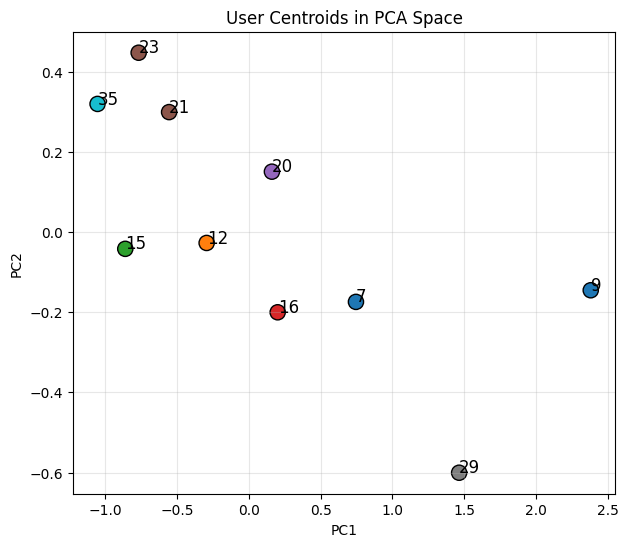

In [10]:
# ============================================================
# 6. Per-user cluster centroids (optional)
# ============================================================

users = np.unique(user_ids)
centroids = []

for u in users:
    Z_u = Z2[user_ids == u]
    centroids.append(Z_u.mean(axis=0))

centroids = np.array(centroids)

plt.figure(figsize=(7,6))
plt.scatter(centroids[:,0], centroids[:,1], c=users, cmap="tab10", s=120, edgecolors='k')
for i, u in enumerate(users):
    plt.text(centroids[i,0], centroids[i,1], str(u), fontsize=12)

plt.title("User Centroids in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.savefig("mouse_centroids.png", dpi=200, bbox_inches="tight")
plt.show()